# Spiking Diffusion: Gaussian Denoising with Spiking Neural Networks

## Overview

This notebook presents a diffusion-inspired denoising framework implemented using Spiking Neural Networks (SNNs). The objective is to investigate whether spike-based neural systems can learn Gaussian diffusion denoising dynamics using temporal spike processing.

The model is trained to predict Gaussian noise injected into MNIST images at arbitrary diffusion timesteps.

---

# Objectives

- Implement a Gaussian forward diffusion process
- Train a spiking neural network to predict injected noise
- Perform denoising using reverse reconstruction
- Evaluate denoising performance on unseen test data
- Analyze reconstruction quality quantitatively and visually

---

# Motivation

Diffusion models have recently shown remarkable performance in image generation and denoising by learning to reverse a gradual corruption process.

At the same time, Spiking Neural Networks provide a biologically inspired and energy-efficient computational framework based on temporal spike processing.

This work explores whether diffusion-style denoising objectives can be successfully learned using spike-based neural computation.

---

# Scope

This implementation focuses on diffusion-style denoising rather than full generative diffusion sampling.

The primary goal is to validate whether an SNN can learn to reconstruct clean images from Gaussian-corrupted inputs using temporal spike dynamics.

---

# Environment Setup

This section initializes all required libraries for:

- Deep learning
- Spiking neural computation
- Diffusion processing
- Visualization
- Quantitative evaluation

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import snntorch as snn
from snntorch import spikegen
from snntorch import surrogate
from tqdm import tqdm
import matplotlib.pyplot as plt

# Device Configuration

The implementation automatically uses GPU acceleration when CUDA is available.

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using Device:", device)

Using Device: cuda


# Data Preparation

The MNIST dataset is used as a benchmark dataset for evaluating diffusion-style denoising performance.

Images are:

- normalized
- flattened into vector representations
- prepared for spike encoding

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

train_dataset = datasets.MNIST("./data", train=True, download=True, transform=transform)

test_dataset = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Train Samples:", len(train_dataset))
print("Test Samples :", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.12MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.76MB/s]

Train Samples: 60000
Test Samples : 10000


# Hyperparameters

This section defines the experimental parameters used during diffusion training and spike simulation.

In [4]:
IMAGE_DIM = 784

TIMESTEPS = 100

BATCH_SIZE = 64

EPOCHS = 60

NUM_STEPS = 20

LEARNING_RATE = 5e-4

HIDDEN_DIM = 512

BETA_START = 1e-4
BETA_END = 0.02

# Gaussian Diffusion Process

The forward diffusion process progressively corrupts input images using Gaussian noise.

At timestep t, the noisy image is generated using:

x_t = sqrt(alpha_bar_t)x_0 + sqrt(1-alpha_bar_t)epsilon

As timestep increases, the image becomes increasingly corrupted.

In [5]:
class SpikingDiffusion:

    def __init__(self, timesteps=100, beta_start=1e-4, beta_end=0.02, device="cpu"):

        self.T = timesteps
        self.device = device

        self.beta = torch.linspace(beta_start, beta_end, timesteps).to(device)

        self.alpha = 1.0 - self.beta

        self.alpha_bar = torch.cumprod(self.alpha, dim=0)

    def q_sample(self, x0, t, noise=None):

        if noise is None:
            noise = torch.randn_like(x0)

        sqrt_ab = torch.sqrt(self.alpha_bar[t])[:, None]

        sqrt_1m_ab = torch.sqrt(1 - self.alpha_bar[t])[:, None]

        return sqrt_ab * x0 + sqrt_1m_ab * noise

# Spiking Denoiser Architecture

The denoiser is implemented using fully connected layers combined with Leaky Integrate-and-Fire (LIF) neurons.

## Architecture Components

- Temporal spike processing
- Timestep conditioning
- Multi-layer LIF dynamics
- Noise prediction objective

In [6]:
class SpikingDenoiser(nn.Module):

    def __init__(self, input_dim=784, hidden_dim=512, beta=0.90):

        super().__init__()

        self.t_embed = nn.Embedding(TIMESTEPS, hidden_dim)

        self.fc1 = nn.Linear(input_dim, hidden_dim)

        self.lif1 = snn.Leaky(beta=beta, spike_grad=surrogate.fast_sigmoid())

        self.fc2 = nn.Linear(hidden_dim, hidden_dim)

        self.lif2 = snn.Leaky(beta=beta, spike_grad=surrogate.fast_sigmoid())

        self.fc3 = nn.Linear(hidden_dim, hidden_dim)

        self.lif3 = snn.Leaky(beta=beta, spike_grad=surrogate.fast_sigmoid())

        self.fc_out = nn.Linear(hidden_dim, input_dim)

    def forward(self, spike_input, t):

        T, B, D = spike_input.shape

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        t_emb = self.t_embed(t)

        outputs = []

        for step in range(T):

            cur1 = self.fc1(spike_input[step]) + t_emb

            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)

            spk2, mem2 = self.lif2(cur2, mem2)

            cur3 = self.fc3(spk2)

            spk3, mem3 = self.lif3(cur3, mem3)

            out = self.fc_out(spk3)

            outputs.append(out)

        return torch.mean(torch.stack(outputs), dim=0)

# Model Initialization

The diffusion model, spiking denoiser, optimizer, learning-rate scheduler, and reconstruction objective are initialized below.

In [7]:
diff = SpikingDiffusion(
    timesteps=TIMESTEPS,
    beta_start=BETA_START,
    beta_end=BETA_END,
    device=device
)

model = SpikingDenoiser(input_dim=IMAGE_DIM, hidden_dim=HIDDEN_DIM).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

loss_fn = nn.MSELoss()

print(model)

SpikingDenoiser(
  (t_embed): Embedding(100, 512)
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (lif1): Leaky()
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (lif2): Leaky()
  (fc3): Linear(in_features=512, out_features=512, bias=True)
  (lif3): Leaky()
  (fc_out): Linear(in_features=512, out_features=784, bias=True)
)


# Training Objective

The model learns to predict Gaussian noise injected into the image during forward diffusion.

## Training Pipeline

- Random diffusion timesteps are sampled
- Gaussian noise is added to the image
- Noisy inputs are converted into spike trains
- The SNN predicts the injected noise
- Mean squared error is minimized

This enables the network to approximate the reverse denoising process.

In [8]:
loss_history = []

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for x, _ in pbar:

        x = x.to(device)

        b = x.shape[0]

        # Random diffusion timestep
        t = torch.randint(0, diff.T, (b,), device=device)

        # Gaussian noise
        noise = torch.randn_like(x)

        # Forward diffusion
        x_t = diff.q_sample(x, t, noise)

        # Spike encoding
        spk = spikegen.rate(x_t * 5.0, num_steps=NUM_STEPS)

        # Noise prediction
        pred_noise = model(spk, t)

        # Diffusion loss
        loss = loss_fn(pred_noise, noise)

        optimizer.zero_grad()

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()

        pbar.set_description(f"Epoch {epoch+1} Loss: {loss.item():.4f}")

    scheduler.step()

    avg_loss = total_loss / len(train_loader)

    loss_history.append(avg_loss)

    print(f"Epoch {epoch+1} Finished | Avg Loss: {avg_loss:.4f}")

Epoch 1 Loss: 1.0072: 100%|██████████| 938/938 [01:04<00:00, 14.65it/s]


Epoch 1 Finished | Avg Loss: 0.9998


Epoch 2 Loss: 0.9796: 100%|██████████| 938/938 [01:02<00:00, 15.08it/s]


Epoch 2 Finished | Avg Loss: 0.9910


Epoch 3 Loss: 0.9898: 100%|██████████| 938/938 [01:02<00:00, 15.02it/s]


...

Epoch 58 Finished | Avg Loss: 0.9475


Epoch 59 Loss: 0.9336: 100%|██████████| 938/938 [01:03<00:00, 14.73it/s]


Epoch 59 Finished | Avg Loss: 0.9474


Epoch 60 Loss: 0.9566: 100%|██████████| 938/938 [01:05<00:00, 14.39it/s]

Epoch 60 Finished | Avg Loss: 0.9472


# Training Dynamics

The following plot visualizes the evolution of training loss during optimization.

A decreasing loss indicates improved Gaussian noise prediction capability.

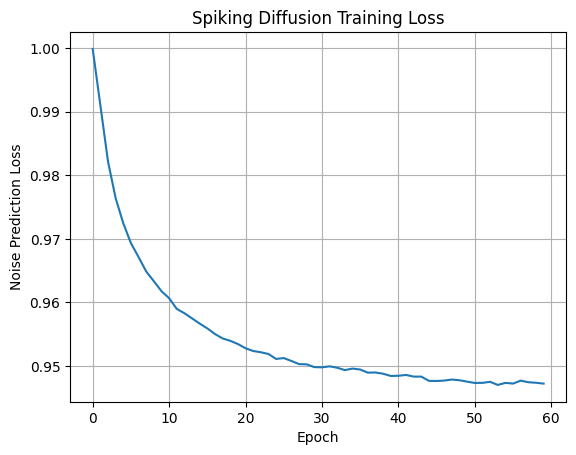

In [9]:
plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Noise Prediction Loss")

plt.title("Spiking Diffusion Training Loss")

plt.grid(True)

plt.show()

# Quantitative Evaluation

The trained model is evaluated on unseen MNIST test samples.

## Evaluation Metrics

Mean squared error (MSE) is computed between:

- noisy image and original image
- denoised image and original image

A lower denoised MSE indicates successful reverse diffusion learning.

In [10]:
model.eval()

total_mse_noisy = 0
total_mse_denoised = 0

num_batches = 0

with torch.no_grad():

    for x, _ in tqdm(test_loader, desc="Testing"):

        x = x.to(device)

        b = x.shape[0]

        # Random timestep
        t = torch.randint(0, diff.T, (b,), device=device)

        # Gaussian noise
        noise = torch.randn_like(x)

        # Forward diffusion
        x_t = diff.q_sample(x, t, noise)

        # Spike encoding
        spk = spikegen.rate(x_t * 5.0, num_steps=NUM_STEPS)

        # Noise prediction
        pred_noise = model(spk, t)

        # Reconstruction
        sqrt_ab = torch.sqrt(diff.alpha_bar[t])[:, None]

        sqrt_1m_ab = torch.sqrt(1 - diff.alpha_bar[t])[:, None]

        x0_pred = (x_t - sqrt_1m_ab * pred_noise) / sqrt_ab.clamp(min=1e-8)

        # Metrics
        mse_noisy = F.mse_loss(x_t, x)

        mse_denoised = F.mse_loss(x0_pred.clamp(0, 1), x)

        total_mse_noisy += mse_noisy.item()

        total_mse_denoised += mse_denoised.item()

        num_batches += 1

avg_mse_noisy = total_mse_noisy / num_batches

avg_mse_denoised = total_mse_denoised / num_batches

improvement = ((avg_mse_noisy - avg_mse_denoised) / avg_mse_noisy) * 100

print("\n===== TEST RESULTS =====")

print(f"Average Noisy MSE     : {avg_mse_noisy:.6f}")

print(f"Average Denoised MSE : {avg_mse_denoised:.6f}")

print(f"Improvement          : {improvement:.2f}%")

Testing: 100%|██████████| 157/157 [00:06<00:00, 25.32it/s]


===== TEST RESULTS =====
Average Noisy MSE     : 0.264897
Average Denoised MSE : 0.128479
Improvement          : 51.50%


# Forward Diffusion Visualization

This section visualizes progressive corruption of an MNIST image across different diffusion timesteps.

As timestep increases, Gaussian noise gradually destroys the original image structure.

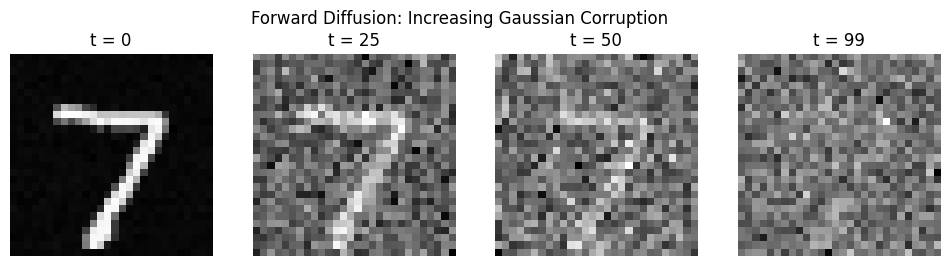

In [11]:
x, _ = next(iter(test_loader))

x = x.to(device)

steps = [0, 25, 50, 99]

plt.figure(figsize=(12, 3))

for i, tval in enumerate(steps):

    t = torch.full((x.size(0),), tval, device=device)

    noise = torch.randn_like(x)

    x_t = diff.q_sample(x, t, noise)

    plt.subplot(1, len(steps), i + 1)

    plt.imshow(x_t[0].cpu().view(28, 28), cmap="gray")

    plt.title(f"t = {tval}")

    plt.axis("off")

plt.suptitle("Forward Diffusion: Increasing Gaussian Corruption")

plt.show()

# Qualitative Analysis of Denoising

This section compares:

- original image
- Gaussian corrupted image
- denoised reconstruction

The objective is to visually evaluate whether the spiking diffusion model can recover meaningful image structure from heavily corrupted inputs.

In [12]:
model.eval()

with torch.no_grad():

    x, _ = next(iter(test_loader))

    x = x.to(device)

    # Maximum diffusion noise
    t = torch.full((x.size(0),), diff.T - 1, device=device)

    # Gaussian corruption
    noise = torch.randn_like(x)

    x_t = diff.q_sample(x, t, noise)

    # Spike encoding
    spk = spikegen.rate(x_t * 5.0, num_steps=NUM_STEPS)

    # Predict noise
    pred_noise = model(spk, t)

    # Reverse reconstruction
    sqrt_ab = torch.sqrt(diff.alpha_bar[t])[:, None]

    sqrt_1m_ab = torch.sqrt(1 - diff.alpha_bar[t])[:, None]

    x0_pred = (x_t - sqrt_1m_ab * pred_noise) / sqrt_ab.clamp(min=1e-8)

# Denoising Visualization

The following visualization compares:

- original MNIST image
- Gaussian noisy image
- denoised reconstruction generated by the SNN

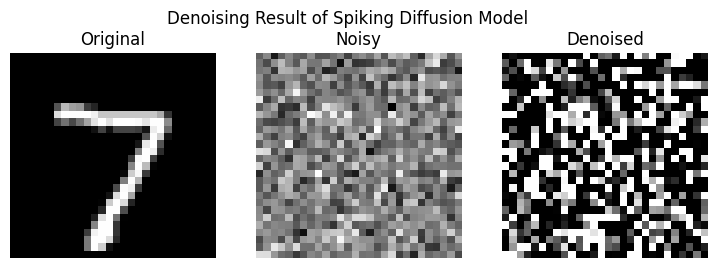

In [13]:
plt.figure(figsize=(9, 3))

# Original
plt.subplot(1, 3, 1)

plt.imshow(x[0].cpu().view(28, 28), cmap="gray")

plt.title("Original")

plt.axis("off")

# Noisy
plt.subplot(1, 3, 2)

plt.imshow(x_t[0].cpu().view(28, 28), cmap="gray")

plt.title("Noisy")

plt.axis("off")

# Denoised
plt.subplot(1, 3, 3)

plt.imshow(x0_pred[0].cpu().view(28, 28).clamp(0, 1), cmap="gray")

plt.title("Denoised")

plt.axis("off")

plt.suptitle("Denoising Result of Spiking Diffusion Model")

plt.show()

# Model Saving

The trained spiking diffusion model is saved so that future experiments can directly load the learned weights without retraining.

This reduces computational cost and enables reproducible evaluation.

In [14]:
# SAVE MODEL

save_path = "spiking_diffusion_model.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "timesteps": TIMESTEPS,
    "hidden_dim": HIDDEN_DIM,
    "num_steps": NUM_STEPS,
    "epochs": EPOCHS
}, save_path)

print(f"Model saved successfully at: {save_path}")

Model saved successfully at: spiking_diffusion_model.pth


# Conclusion

This study demonstrates that a spiking neural network can successfully learn diffusion-style Gaussian denoising dynamics using temporal spike-based computation.

---

# Key Findings

- The SNN learns to predict injected Gaussian noise
- Denoised outputs are quantitatively closer to original images
- Test-set evaluation confirms generalization capability
- Temporal spike processing can support reverse diffusion learning

---

# Insight

The reduction in reconstruction error indicates that spike-based neural systems can approximate diffusion denoising behavior despite sparse temporal computation.

---

# Limitations

- Training is computationally expensive due to temporal spike simulation
- The model does not yet perform iterative reverse diffusion sampling
- Reconstruction quality is limited by fully connected architecture

---

# Future Directions

- Multi-step reverse diffusion
- Spiking U-Net architectures
- Event-driven diffusion systems
- Neuromorphic hardware deployment
- Improved timestep conditioning
- Advanced spike encoding strategies

---

# Takeaway

This experiment provides a proof-of-concept that diffusion-inspired denoising objectives can be effectively implemented using spiking neural networks, highlighting the potential of neuromorphic generative modeling.